# 8 · Approximator Comparison: replacing the D4PG neural nets

The semi-analytical HHK kernel (`feat/semi-analytical-bootstrap`) made the TD
target **deterministic**, so the actor/critic **function approximator** is the
remaining lever for speed and quality. This notebook compares four
gradient-compatible, C++-portable approximators against the current
`2×64 SiLU + LayerNorm` net (`nn`):

| tag | approximator | trainable head | feature front-end |
|---|---|---|---|
| `nn` | current MLP | full 2×64 net | raw state (+ robust norm) |
| `poly` | Chebyshev tensor basis | linear | `CuratedFeatures` → `T₁..T_d` |
| `rff` | Random Fourier Features | linear | `CuratedFeatures` → `√(2/D)·cos(Ωz+b)` |
| `rbf` | Radial Basis Function net | linear (+bw) | `CuratedFeatures` → `exp(-‖z−c‖²/2σ²)` |
| `tiny_nn` | compressed MLP | 1×W net | `CuratedFeatures` → `SiLU(Wz)` |

**Why these four are valid** (Silver et al. 2014, DPG Thm 3): DDPG/D4PG updates
the actor through the action-gradient `∇_a Q`. A critic that is **linear in a
feature map of the action** is provably compatible with the deterministic policy
gradient. All four are differentiable w.r.t. the action *and* their own
parameters (autograd-verified in `tools/test_approximators.py`), which rules in
feature-map + linear-head models and rules out non-differentiable methods
(gradient-boosted trees).

**Shared design.** Every approximator consumes a single curated, fixed-scale
feature vector (`src/networks.py::CuratedFeatures`): log-moneyness, ttm,
inventory (remaining/exercised), the OU/jump factors X,Y, days-since-exercise,
and three domain cross-terms. Scales are *fixed* (not running stats) because the
HHK process is identical across the four contract regimes — only `c_cost`,
`gamma_cost` vary. This is what keeps the C++ port a `feature_map + gemv`.


In [1]:
import os, sys, json, glob, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'Jupyter Notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import torch
from tools import stats_analysis as sa

APPROX = ['nn', 'poly', 'rff', 'rbf', 'tiny_nn']
REGIMES = ['g1', 'g15', 'g2', 'nocost']
REGIME_LABEL = {'g1': 'c=0.04, γ=1', 'g15': 'c=0.04, γ=1.5',
                'g2': 'c=0.04, γ=2 (focal)', 'nocost': 'c=0, γ=1'}
SWEEP_DIR = ROOT / 'logs' / '_sweep_approx'
print('ROOT =', ROOT)
print('sweep dir exists:', SWEEP_DIR.exists())


ROOT = /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options
sweep dir exists: True


## 1 · Speed: the hard acceptance gate

Each contender must be **faster than the NN per actor+critic update**. This is a
clean, single-thread microbenchmark of one full update step (critic MSE + actor
`−Q` policy gradient), isolated from the kernel quadrature and CPU contention
that confound end-to-end wall-clock.


In [2]:
import time, functools
from src.networks import Actor, Critic, BasisActor, BasisCritic
torch.set_num_threads(1)

B = 128
torch.manual_seed(0)
state = torch.rand(B, 9); state[:, 5] = torch.rand(B) * 0.6 + 0.7   # spot ~ strike(1.0)
act = torch.rand(B, 1); tgt = torch.rand(B, 1)
CFG = dict(strike=1.0, use_cross=True, degree=3, rff_dim=256, lengthscale=1.0,
           rbf_centers=128, bandwidth=1.0, width=32, activation='silu')

def _make(kind):
    if kind == 'nn':
        return (Actor(9, 1, 0, action_output='beta_sigmoid_3.0'), Critic(9, 1, 0))
    return (BasisActor(9, 1, 0, action_output='beta_sigmoid_3.0', feature_kind=kind, feature_cfg=CFG),
            BasisCritic(9, 1, 0, feature_kind=kind, feature_cfg=CFG))

def _bench(kind, iters=2000, warmup=50):
    a, cr = _make(kind)
    oa = torch.optim.Adam(a.parameters(), 1e-4); oc = torch.optim.Adam(cr.parameters(), 1e-4)
    lf = torch.nn.MSELoss()
    def step():
        oc.zero_grad(); lf(cr(state, act), tgt).backward(); oc.step()
        oa.zero_grad(); (-cr(state, a(state)).mean()).backward(); oa.step()
    for _ in range(warmup): step()
    t0 = time.perf_counter()
    for _ in range(iters): step()
    dt = time.perf_counter() - t0
    n_params = sum(p.numel() for p in a.parameters()) + sum(p.numel() for p in cr.parameters())
    return iters / dt, n_params

speed = {k: _bench(k) for k in APPROX}
base = speed['nn'][0]
print(f"{'approx':<9}{'updates/sec':>12}{'params':>9}{'speedup':>9}")
for k in APPROX:
    ups, npar = speed[k]
    print(f"{k:<9}{ups:>12.1f}{npar:>9}{ups/base:>8.2f}x")


approx    updates/sec   params  speedup
nn              697.1    10306    1.00x
poly           1460.1       97    2.09x
rff            1084.0      514    1.56x
rbf            1132.8      258    1.63x
tiny_nn        1220.0      802    1.75x


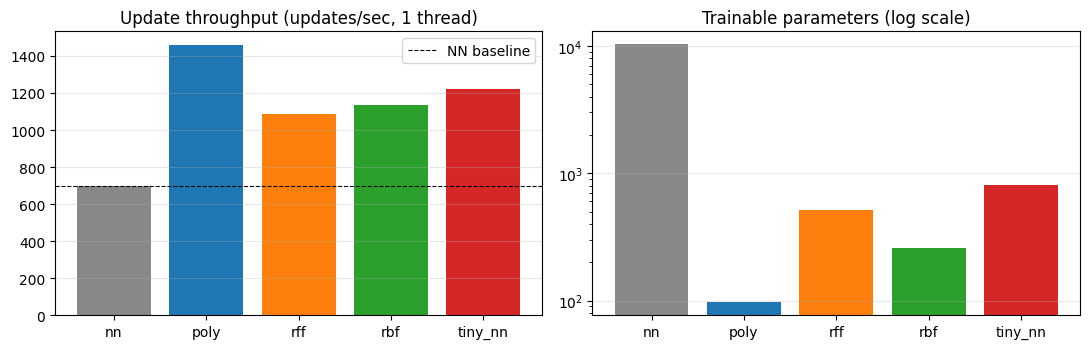

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ups = [speed[k][0] for k in APPROX]; npar = [speed[k][1] for k in APPROX]
colors = ['#888'] + ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax[0].bar(APPROX, ups, color=colors); ax[0].set_title('Update throughput (updates/sec, 1 thread)')
ax[0].axhline(speed['nn'][0], ls='--', c='k', lw=0.8, label='NN baseline'); ax[0].legend()
ax[1].bar(APPROX, npar, color=colors); ax[1].set_yscale('log'); ax[1].set_title('Trainable parameters (log scale)')
for a_ in ax: a_.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 2 · Mathematical correctness

`tools/test_approximators.py` proves each approximator is sound **before** any
tuning. The core checks:

- **Interface/shape**: actor `(B,9)→(B,1)∈[0,1]`; critic `((B,9),(B,1))→(B,1)`.
- **DPG-compatibility (float64 `gradcheck`)**: `∂Q/∂a`, `∂Q/∂w_c`, `∂a/∂θ_a`
  are finite and match finite differences — the formal proof these are valid
  D4PG approximators.
- **Fitting capacity**: each critic reduces MSE > 50% on a smooth intrinsic-value
  target (no underfitting pathology).
- **Profitability gate**: the STE gate zeros provably-unprofitable exercises.
- **Kernel compatibility**: `expected_critic_target` returns finite `(B,)` for
  every module — the going-forward deterministic target works unchanged.
- **Bit-identical NN guard**: `--approximator=nn` reproduces v61 numerics.


In [4]:
import subprocess
res = subprocess.run([sys.executable, '-m', 'pytest',
                      str(ROOT / 'tools' / 'test_approximators.py'), '-q'],
                     cwd=str(ROOT), capture_output=True, text=True)
print(res.stdout[-800:] or res.stderr[-800:])


.....................................                                    [100%]
37 passed in 2.95s



In [5]:
def load_stage(stage):
    '''Load a sweep CSV into stats_analysis GroupStats; [] if absent.'''
    path = SWEEP_DIR / f'sweep_approx_stage{stage}.csv'
    if not path.exists():
        print(f'[stage {stage}] {path.name} not found — run '
              f'`python tools/sweep_approximators.py --stage {stage}` first.')
        return []
    import csv
    rows = [r for r in csv.DictReader(open(path)) if r.get('status') == 'ok']
    return sa.summarize_groups(rows)

def groups_by(groups, regime=None, n_paths=None):
    out = []
    for g in groups:
        if regime is not None and g.contract != regime: continue
        if n_paths is not None and g.n_paths != n_paths: continue
        out.append(g)
    return out


## 3 · Screening (Stage B): high-power head-to-head

4 regimes × **24 seeds** × 4096 ep, fast kernel (`M_x=2`), 4 workers, all five
contenders. Metric: **Δ% vs LSM** = `(RL/LSM − 1)·100` per seed.

Run with:
```bash
python tools/sweep_approximators.py --stage B --max_workers 4
```
The cells below render once `sweep_approx_stageB.csv` exists.


In [6]:
gB = load_stage('B')
if gB:
    for regime in REGIMES:
        gs = groups_by(gB, regime=regime)
        if gs:
            sa.print_summary(gs, title=f'Stage B — {REGIME_LABEL[regime]}')


[stage B] sweep_approx_stageB.csv not found — run `python tools/sweep_approximators.py --stage B` first.


In [7]:
# Per-regime Δ% strip+box, approximators side by side
if gB:
    fig, axes = plt.subplots(1, len(REGIMES), figsize=(4*len(REGIMES), 4), sharey=True)
    for ax, regime in zip(np.atleast_1d(axes), REGIMES):
        gs = {g.label.split('_')[0]: g for g in groups_by(gB, regime=regime)}
        data, labels = [], []
        for k in APPROX:
            if k in gs:
                data.append(gs[k].deltas); labels.append(k)
        if data:
            ax.boxplot(data, labels=labels, showmeans=True)
            for i, d in enumerate(data, 1):
                ax.scatter(np.full(len(d), i) + np.random.uniform(-.08, .08, len(d)),
                           d, s=10, alpha=.4)
        ax.axhline(0, c='k', lw=.8, ls='--'); ax.set_title(REGIME_LABEL[regime])
        ax.grid(axis='y', alpha=.3)
    np.atleast_1d(axes)[0].set_ylabel('Δ% vs LSM')
    plt.tight_layout(); plt.show()


In [8]:
# Welch / Levene / F-ratio + paired-seed vs the NN baseline, focal regime
if gB:
    for regime in REGIMES:
        gs = groups_by(gB, regime=regime)
        if any(g.label.startswith('nn') for g in gs):
            print(f'\n=== Stage B pairwise vs nn — {REGIME_LABEL[regime]} ===')
            sa.print_pairwise(gs, reference_label=f'nn_{regime}', n_bootstrap=2000)


In [9]:
# Conservative Pareto frontier: Δ% (mean − 1·std) vs wall-clock
if gB:
    fig, ax = plt.subplots(figsize=(7, 5))
    front = set(id(g) for g in sa.conservative_pareto(gB))
    for g in gB:
        k = g.label.split('_')[0]
        on = id(g) in front
        ax.scatter(g.wall_mean, g.mean, s=70 if on else 35,
                   edgecolor='k' if on else 'none',
                   label=None, alpha=.8)
        ax.annotate(g.label, (g.wall_mean, g.mean), fontsize=7, alpha=.7)
    ax.set_xlabel('mean wall-clock (s)'); ax.set_ylabel('mean Δ% vs LSM')
    ax.set_title('Δ% vs cost — bold = conservative Pareto front')
    ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## 4 · Finalist validation (Stage C): accurate kernel, paper scale

Finalists × 4 regimes × **6 seeds** × {8192, 32768} ep, **accurate** kernel
(`M_x=4, M_per_k=4, N_max=2`), 3 workers.

```bash
python tools/sweep_approximators.py --stage C --max_workers 3
```


In [10]:
gC = load_stage('C')
if gC:
    for n_paths in sorted({g.n_paths for g in gC}):
        for regime in REGIMES:
            gs = groups_by(gC, regime=regime, n_paths=n_paths)
            if gs:
                sa.print_summary(gs, title=f'Stage C — {REGIME_LABEL[regime]} @ {n_paths} ep')


[stage C] sweep_approx_stageC.csv not found — run `python tools/sweep_approximators.py --stage C` first.


## 5 · Winner selection

Decision rule (encoded below): among contenders that **clear the speed gate**
(faster than `nn` in §1), pick the one with the best **robust Δ%** across all
four regimes — we use the mean over regimes of each regime's conservative score
(`mean − 1·std`), so a winner must be both good *and* low-variance everywhere.
Ties break on wall-clock.


In [11]:
def robust_score(groups, stage_label='Stage B'):
    by_k = {}
    for g in groups:
        by_k.setdefault(g.label.split('_')[0], []).append(g)
    rows = []
    for k, gs in by_k.items():
        cons = np.mean([g.conservative for g in gs])      # mean over regimes of (mean − std)
        meanΔ = np.mean([g.mean for g in gs])
        wall = np.mean([g.wall_mean for g in gs])
        faster = speed[k][0] >= speed['nn'][0] if k in speed else False
        rows.append((k, meanΔ, cons, wall, faster))
    rows.sort(key=lambda r: (-r[2], r[3]))
    print(f"{stage_label}: robust ranking")
    print(f"{'approx':<9}{'meanΔ%':>9}{'robustΔ%':>10}{'wall(s)':>9}{'speed-gate':>11}")
    for k, m, cons, wall, fast in rows:
        print(f"{k:<9}{m:>9.2f}{cons:>10.2f}{wall:>9.0f}{'PASS' if fast else 'FAIL':>11}")
    eligible = [r for r in rows if r[4]]
    if eligible:
        print(f"\n>>> Winner (speed-gated, robust): {eligible[0][0]}")
    return rows

if gB:
    robust_score(gB, 'Stage B')
if gC:
    robust_score(gC, 'Stage C')
if not gB and not gC:
    print('No sweep data yet — run Stage B/C, then re-run this cell.')


No sweep data yet — run Stage B/C, then re-run this cell.


## 6 · End-to-end C++ port plan

Goal: a **fast, dependency-light, readable** C++ pricer that a reader can follow
as a teaching exercise. The deterministic kernel + linear-head approximator make
this tractable: **no autograd needed** — every gradient has a closed form.

### 6.1 Module map (Python → C++)

| Python | C++ file | Notes |
|---|---|---|
| `simulate_hhk_spot.py` | `hhk_sim.{h,cpp}` | Sobol (or `<random>` + antithetic) draws of X (OU) and Y (compound-Poisson jumps); `S = exp(f(t)+X+Y)`. |
| `swing_env.py` | `swing_env.{h,cpp}` | Plain struct: inventory/refraction bookkeeping, convex-cost reward `q(S−K)⁺ − c·qᵞ`, 9-dim state vector. |
| `swing_contract.py` | `contract.h` | POD struct (strike, maturity, q/Q bounds, c, γ, n_rights). |
| `replay_buffer.py` | `per_buffer.{h,cpp}` | 1:1 port of the Fenwick (sum-tree) PER; the numba kernels become plain loops. |
| `transition_kernel.py` | `kernel.{h,cpp}` | Precompute Gauss–Hermite nodes for X and the QMC jump mesh for Y once; `expected_target` is a small `M`-point quadrature loop. |
| `networks.py` (winner) | `approximator.{h,cpp}` | `CuratedFeatures` + the winning feature map + a `gemv` head. **Closed-form** `∂Q/∂a`, `∂Q/∂w` (below). |
| `agent.py` | `agent.{h,cpp}` | Adam as `axpy`; soft target update `θ⁻ ← τθ + (1−τ)θ⁻`. |
| `run.py` | `main.cpp` | CLI, training loop, LSM benchmark, CSV out. |

Dependencies: **Eigen** (BLAS-style `gemv`/`gemm`) + the standard library. No
Torch, no autograd.

### 6.2 The math the C++ needs (write once, for the winner)

Let `z = CuratedFeatures(s) ∈ ℝ^K` (fixed, differentiable-free transform of the
raw 9-dim state) and `ã = 2a − 1` the centered action.

**Critic** `Q(s,a) = wᵀ φ(z, ã) + b`. Per feature map:

- **poly**: `φ = [ψ, ã·ψ, ã, ã²]`, where `ψ = [T₁(tanh z) … T_d(tanh z)]`
  (Chebyshev, recurrence `T_{n+1}=2xT_n−T_{n−1}`).
  `∂Q/∂a = 2·(w_ψ̃ᵀψ + w_{ã} + 2ã·w_{ã²})` (closed form — the bilinear + quadratic
  action terms). `∂Q/∂w = φ`, `∂Q/∂b = 1`.
- **rff**: `φ = √(2/D)·cos(Ω[z;ã] + β)`. `∂Q/∂a = 2·wᵀ(−√(2/D)·sin(Ω·+β)⊙Ω_{:,last})`.
  Ω, β are frozen constants baked into the binary.
- **rbf**: `φ_i = exp(−‖[z;ã]−c_i‖²/2σ²)`. `∂Q/∂a = 2·Σ_i w_i φ_i·(c_i,last − ã)/σ²`.
- **tiny_nn**: `φ = act(W[z;ã])`. `∂Q/∂a = 2·wᵀ(act'(W·)⊙W_{:,last})`.

**Actor** `a = output_act(w_aᵀ φ_a(z) + b_a)` then the profitability-gate STE:
`q = 1[Π(q_proj) > 0] · q_proj`, gradient passes through as identity. The
beta-sigmoid output and its derivative are elementary.

**Updates** (no autograd):
- Critic: `g_w = (Q − y)·φ`, `g_b = (Q − y)`, Adam step.
- Actor (DPG): `g_{θ_a} = −(∂Q/∂a)·(∂a/∂θ_a)`, where `∂Q/∂a` is the closed form
  above and `∂a/∂θ_a` is one chain step through `output_act` and the linear head.

### 6.3 Suggested build order
1. `hhk_sim` + a Python cross-check on path moments.
2. `contract` + `swing_env` (replay one Python episode, assert identical reward).
3. `kernel` quadrature (assert `expected_target` matches Python to 1e-6).
4. `approximator` for the winner + a numeric-gradient unit test against the
   closed forms (mirror `test_approximators.py`).
5. `per_buffer`, then `agent` + Adam; reproduce a short Δ% run.
6. `main.cpp`: full training + LSM benchmark + CSV, then a regime sweep.

Because the winning approximator is a fixed feature map + one `gemv`, steps 4–5
are a few hundred lines of straight-line, loop-readable C++.


---
### Reproduce
```bash
pytest tools/test_approximators.py -q                 # §2 correctness
python tools/sweep_approximators.py --stage A --max_workers 4   # tune
python tools/sweep_approximators.py --stage B --max_workers 4   # screen (24 seeds)
python tools/sweep_approximators.py --stage C --max_workers 3   # finalists (accurate kernel)
```
After Stage B/C finish, re-run §3–§5 to render the comparison and pick the winner.
